##### ARTI 560 - Computer Vision

## Pose Estimation

### Introduction

Pose estimation is a computer vision task that involves detecting the position of key points on the human body (such as joints like elbows, knees, and shoulders) from images or videos. These keypoints can be used to understand human posture, movement, and actions.

Pose estimation is widely used in applications such as:
- Human action recognition
- Sports analysis
- Healthcare and rehabilitation
- Augmented reality (AR)
- Animation and gaming

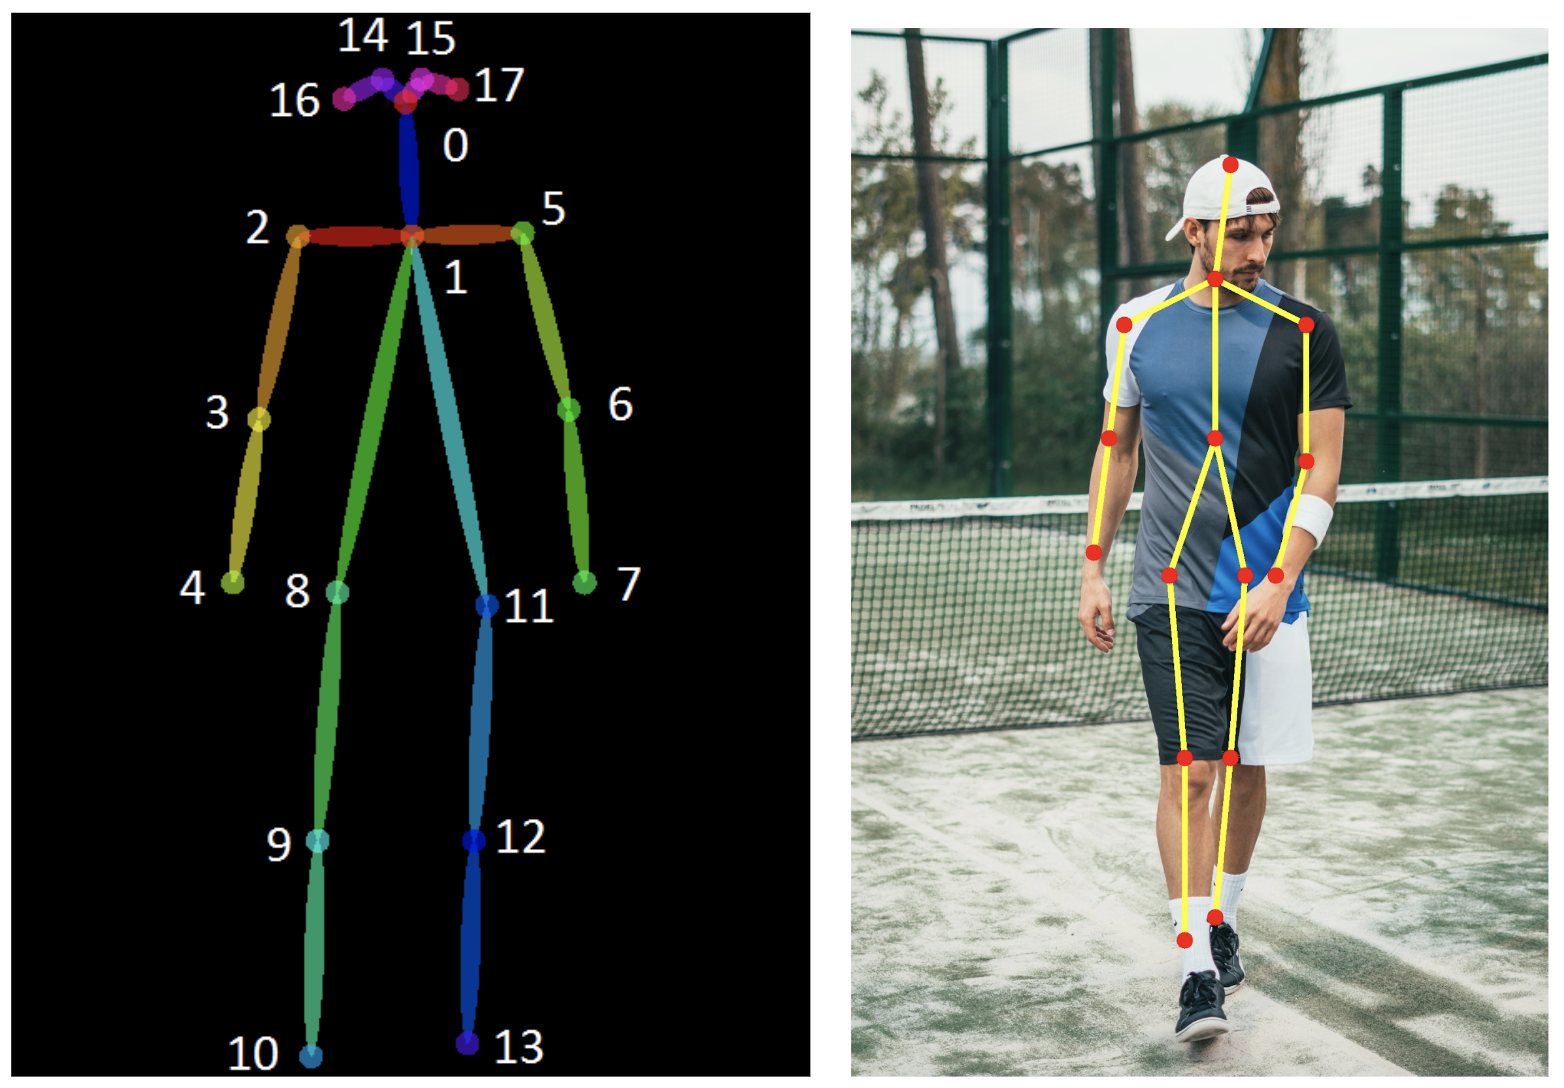

## Single-Person vs Multi-Person Pose Estimation

### Single-Person Pose Estimation
- Focuses on detecting keypoints for **one person** in an image.
- Assumes that the person is already localized (e.g., cropped image).
- Simpler and faster compared to multi-person approaches.
- Commonly used in controlled environments.

### Multi-Person Pose Estimation
- Detects keypoints for **multiple people** in the same image.
- More complex because it must:
  - Detect all individuals
  - Associate keypoints with the correct person
- Typically involves two approaches:
  - Top-down: detect people first, then estimate pose per person
  - Bottom-up: detect all keypoints first, then group them
- Used in real-world scenarios like crowds and surveillance.


## Common Datasets and Models

### COCO (Common Objects in Context)
- One of the most widely used datasets for pose estimation.
- Contains images with multiple people in complex scenes.
- Provides **18 keypoints** per person (e.g., nose, eyes, shoulders, knees).
- Supports multi-person pose estimation tasks.
- Often used to train state-of-the-art deep learning models.

### MPII (Max Planck Institute for Informatics)
- Focuses on human activities in everyday scenes.
- Provides **15 keypoints** per person.
- Includes a wide range of human poses and activities.
- Commonly used for benchmarking single-person pose estimation models.

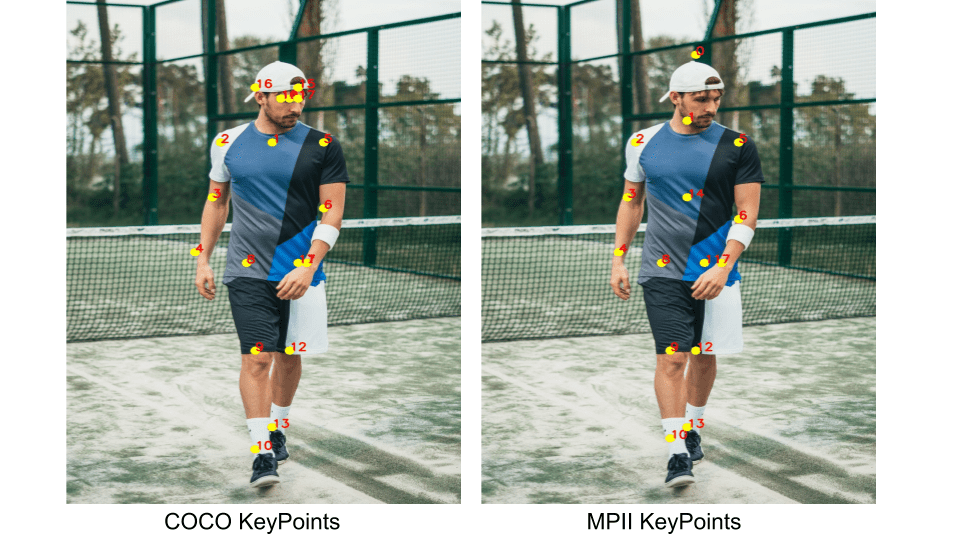


## OpenPose

OpenPose is a popular real-time multi-person pose estimation framework developed by Carnegie Mellon University.

### Key Features:
- Detects multiple people in an image
- Extracts body, hand, and facial keypoints
- Uses a bottom-up approach
- Works in real-time with optimized hardware

### How it Works:
OpenPose first detects all keypoints in the image, then groups them into individual people using Part Affinity Fields (PAFs).


Typical pipeline:
1. Input image
2. Detect keypoints
3. Connect them into a skeleton

### 1. Single-Person Pose Estimation

In [1]:
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Specify the model to be used
MODE = "COCO"

if MODE == "COCO":
    protoFile = "pose/coco/pose_deploy_linevec.prototxt" #the neural network architecture
    weightsFile = "pose/coco/pose_iter_440000.caffemodel"#the trained weights
    nPoints = 18
    POSE_PAIRS = [ [1,0],[1,2],[1,5],[2,3],[3,4],[5,6],[6,7],[1,8],[8,9],[9,10],[1,11],[11,12],[12,13],[0,14],[0,15],[14,16],[15,17]]

elif MODE == "MPI" :
    protoFile = "pose/mpi/pose_deploy_linevec_faster_4_stages.prototxt"
    weightsFile = "pose/mpi/pose_iter_160000.caffemodel"
    nPoints = 15
    POSE_PAIRS = [[0,1], [1,2], [2,3], [3,4], [1,5], [5,6], [6,7], [1,14], [14,8], [8,9], [9,10], [14,11], [11,12], [12,13] ]
    

In [3]:
frame = cv2.imread("./media/single.jpeg")
frameCopy = np.copy(frame)
frameWidth = frame.shape[1]
frameHeight = frame.shape[0]
threshold = 0.1 #set the minimum confidence level for detecting body joints

#### Pass the image through the network

In [4]:
net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile) #load the pretrained Caffe model

inWidth = 368
inHeight = 368

inpBlob = cv2.dnn.blobFromImage(frame, 1.0 / 255, (inWidth, inHeight),
                          (0, 0, 0), swapRB=False, crop=False) # preprocess image into a 4D input tensor (blob)
 
net.setInput(inpBlob) # set the blob as input to the neural network

output = net.forward() # run inference through the network

H = output.shape[2] # height of output heatmaps
W = output.shape[3] # width of output heatmaps
print(output.shape)

(1, 57, 46, 46)


#### gather the points and plot the keypoints and the skeleton figure

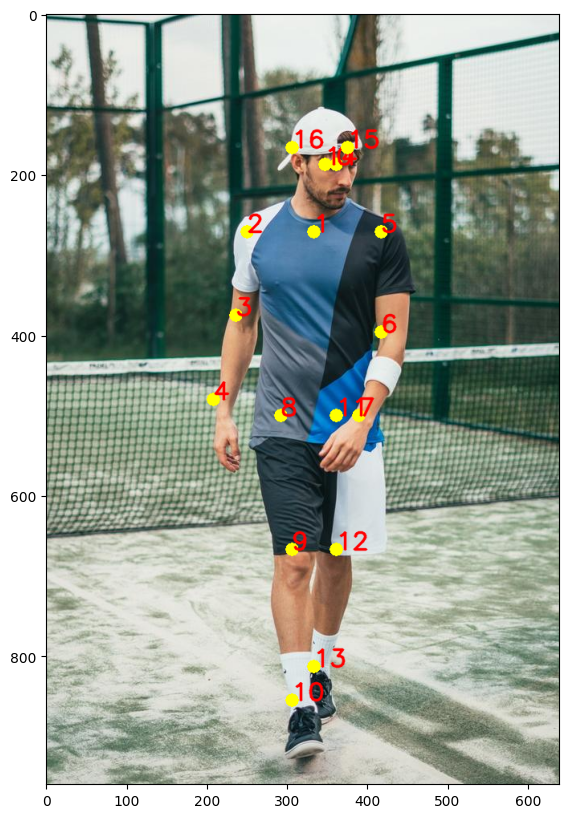

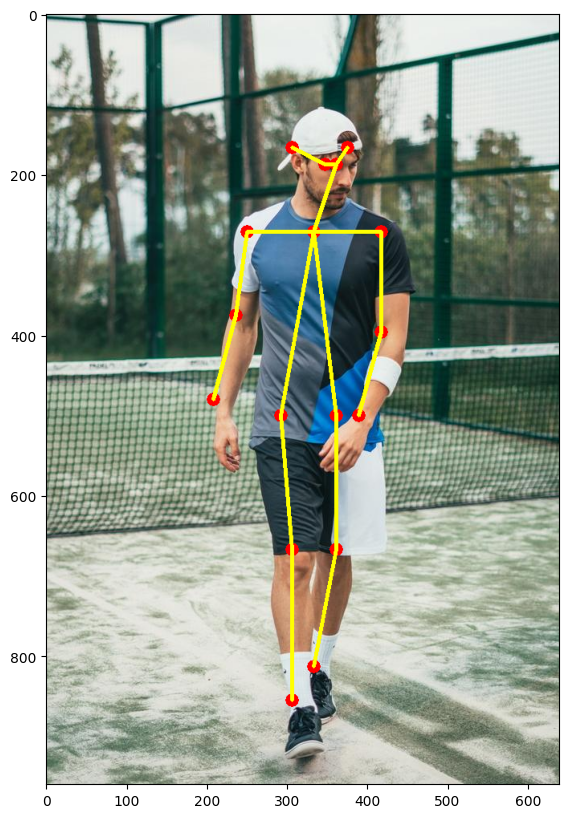

In [5]:
# Empty list to store the detected keypoints
points = []

for i in range(nPoints):
    # confidence map of corresponding body's part.
    probMap = output[0, i, :, :]

    # Find global maxima of the probMap.
    minVal, prob, minLoc, point = cv2.minMaxLoc(probMap)
    
    # Scale the point to fit on the original image
    x = (frameWidth * point[0]) / W
    y = (frameHeight * point[1]) / H

    if prob > threshold : 
        cv2.circle(frameCopy, (int(x), int(y)), 8, (0, 255, 255), thickness=-1, lineType=cv2.FILLED)
        cv2.putText(frameCopy, "{}".format(i), (int(x), int(y)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2, lineType=cv2.LINE_AA)
        cv2.circle(frame, (int(x), int(y)), 8, (0, 0, 255), thickness=-1, lineType=cv2.FILLED)

        # Add the point to the list if the probability is greater than the threshold
        points.append((int(x), int(y)))
    else :
        points.append(None)

# Draw Skeleton
for pair in POSE_PAIRS:
    partA = pair[0]
    partB = pair[1]

    if points[partA] and points[partB]:
        cv2.line(frame, points[partA], points[partB], (0, 255, 255), 3)

plt.figure(figsize=[10,10])
plt.imshow(cv2.cvtColor(frameCopy, cv2.COLOR_BGR2RGB))
plt.figure(figsize=[10,10])
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

### 2. Multi-Person Pose Estimation

#### Let us load an image with multiple people and check what the model sees

In [6]:
image1 = cv2.imread("./media/multiple.jpeg")
frameWidth = image1.shape[1]
frameHeight = image1.shape[0]
threshold = 0.1

#### Load the network and pass the image through the network

In [7]:
net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile)

inWidth = 368
inHeight = 368
inpBlob = cv2.dnn.blobFromImage(image1, 1.0 / 255, (inWidth, inHeight),
                          (0, 0, 0), swapRB=False, crop=False)

net.setInput(inpBlob)
output = net.forward()
H = output.shape[2]
W = output.shape[3]
print(output.shape)

(1, 57, 46, 46)


#### Slice a probability map from the output for a specific keypoint and plot the heatmap ( after resizing ) on the image itself

(np.float64(-0.5), np.float64(1279.5), np.float64(1071.5), np.float64(-0.5))

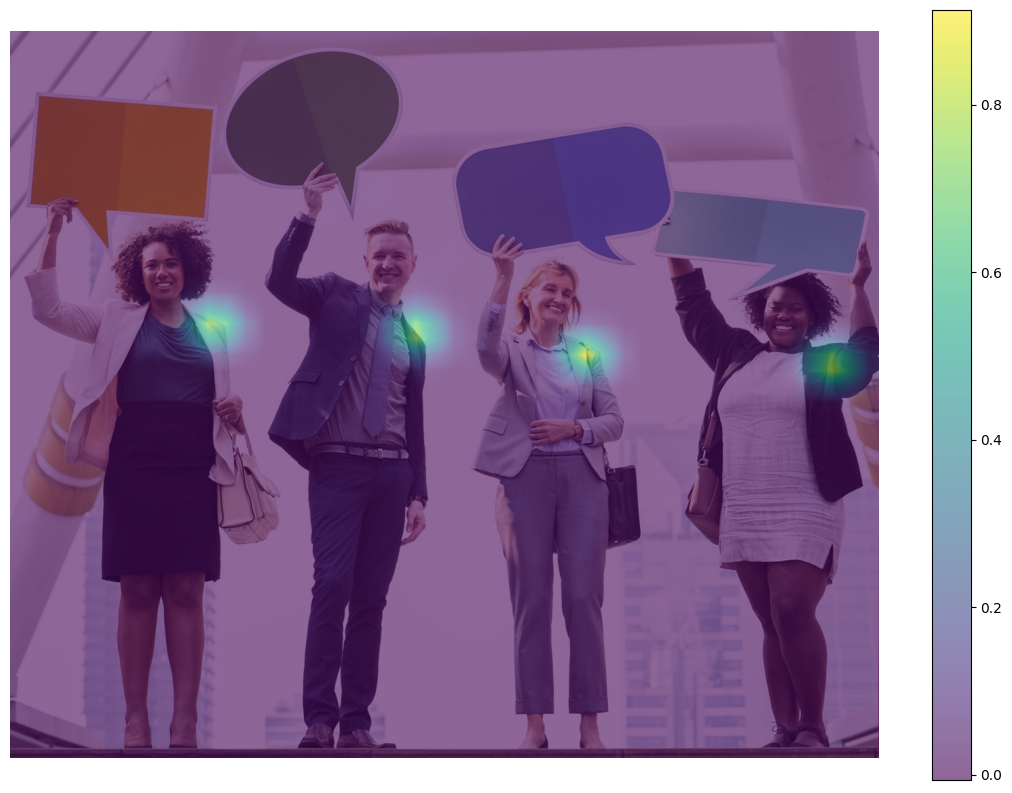

In [14]:
i = 5
probMap = output[0, i, :, :]
probMap = cv2.resize(probMap, (image1.shape[1], image1.shape[0]))
plt.figure(figsize=[14,10])
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.imshow(probMap, alpha=0.6)
plt.colorbar()
plt.axis("off")

#### Similarly plot the affinity map on the image

(np.float64(-0.5), np.float64(1279.5), np.float64(1071.5), np.float64(-0.5))

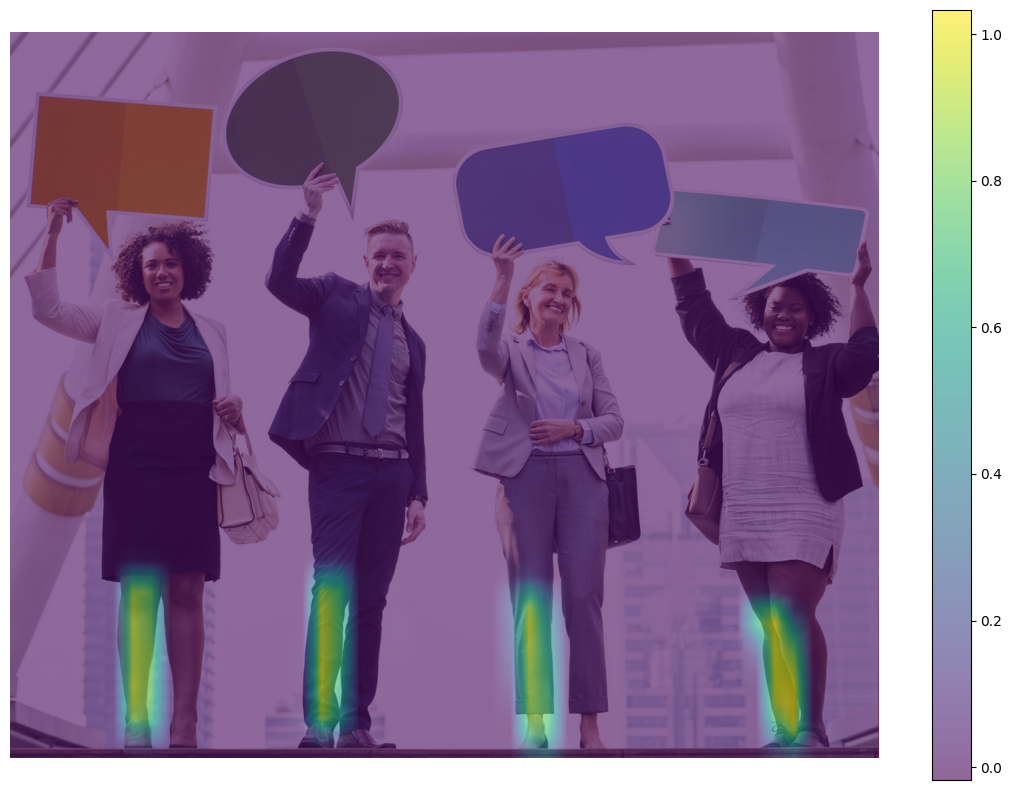

In [15]:
i = 24
probMap = output[0, i, :, :]
probMap = cv2.resize(probMap, (image1.shape[1], image1.shape[0]))
plt.figure(figsize=[14,10])
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.imshow(probMap, alpha=0.6)
plt.colorbar()
plt.axis("off")

In [8]:
protoFile = "pose/coco/pose_deploy_linevec.prototxt"
weightsFile = "pose/coco/pose_iter_440000.caffemodel"
nPoints = 18
# COCO Output Format
keypointsMapping = ['Nose', 'Neck', 'R-Sho', 'R-Elb', 'R-Wr', 'L-Sho', 
                    'L-Elb', 'L-Wr', 'R-Hip', 'R-Knee', 'R-Ank', 'L-Hip', 
                    'L-Knee', 'L-Ank', 'R-Eye', 'L-Eye', 'R-Ear', 'L-Ear']

POSE_PAIRS = [[1,2], [1,5], [2,3], [3,4], [5,6], [6,7],
              [1,8], [8,9], [9,10], [1,11], [11,12], [12,13],
              [1,0], [0,14], [14,16], [0,15], [15,17],
              [2,17], [5,16] ]

# index of pafs correspoding to the POSE_PAIRS
# e.g for POSE_PAIR(1,2), the PAFs are located at indices (31,32) of output, Similarly, (1,5) -> (39,40) and so on.
mapIdx = [[31,32], [39,40], [33,34], [35,36], [41,42], [43,44], 
          [19,20], [21,22], [23,24], [25,26], [27,28], [29,30], 
          [47,48], [49,50], [53,54], [51,52], [55,56], 
          [37,38], [45,46]]

colors = [ [0,100,255], [0,100,255], [0,255,255], [0,100,255], [0,255,255], [0,100,255],
         [0,255,0], [255,200,100], [255,0,255], [0,255,0], [255,200,100], [255,0,255],
         [0,0,255], [255,0,0], [200,200,0], [255,0,0], [200,200,0], [0,0,0]]


In [9]:
# Find the Keypoints using Non Maximum Suppression on the Confidence Map
def getKeypoints(probMap, threshold=0.1):
    
    mapSmooth = cv2.GaussianBlur(probMap,(3,3),0,0)

    mapMask = np.uint8(mapSmooth>threshold)
    keypoints = []
    
    #find the blobs
    contours, _ = cv2.findContours(mapMask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    #for each blob find the maxima
    for cnt in contours:
        blobMask = np.zeros(mapMask.shape)
        blobMask = cv2.fillConvexPoly(blobMask, cnt, 1)
        maskedProbMap = mapSmooth * blobMask
        _, maxVal, _, maxLoc = cv2.minMaxLoc(maskedProbMap)
        keypoints.append(maxLoc + (probMap[maxLoc[1], maxLoc[0]],))

    return keypoints

In [10]:
# Find valid connections between the different joints of a all persons present
def getValidPairs(output):
    valid_pairs = []
    invalid_pairs = []
    n_interp_samples = 10
    paf_score_th = 0.1
    conf_th = 0.7
    # loop for every POSE_PAIR
    for k in range(len(mapIdx)):
        # A->B constitute a limb
        pafA = output[0, mapIdx[k][0], :, :]
        pafB = output[0, mapIdx[k][1], :, :]
        pafA = cv2.resize(pafA, (frameWidth, frameHeight))
        pafB = cv2.resize(pafB, (frameWidth, frameHeight))

        # Find the keypoints for the first and second limb
        candA = detected_keypoints[POSE_PAIRS[k][0]]
        candB = detected_keypoints[POSE_PAIRS[k][1]]
        nA = len(candA)
        nB = len(candB)

        # If keypoints for the joint-pair is detected
        # check every joint in candA with every joint in candB 
        # Calculate the distance vector between the two joints
        # Find the PAF values at a set of interpolated points between the joints
        # Use the above formula to compute a score to mark the connection valid
        
        if( nA != 0 and nB != 0):
            valid_pair = np.zeros((0,3))
            for i in range(nA):
                max_j=-1
                maxScore = -1
                found = 0
                for j in range(nB):
                    # Find d_ij
                    d_ij = np.subtract(candB[j][:2], candA[i][:2])
                    norm = np.linalg.norm(d_ij)
                    if norm:
                        d_ij = d_ij / norm
                    else:
                        continue
                    # Find p(u)
                    interp_coord = list(zip(np.linspace(candA[i][0], candB[j][0], num=n_interp_samples),
                                            np.linspace(candA[i][1], candB[j][1], num=n_interp_samples)))
                    # Find L(p(u))
                    paf_interp = []
                    for k in range(len(interp_coord)):
                        paf_interp.append([pafA[int(round(interp_coord[k][1])), int(round(interp_coord[k][0]))],
                                           pafB[int(round(interp_coord[k][1])), int(round(interp_coord[k][0]))] ]) 
                    # Find E
                    paf_scores = np.dot(paf_interp, d_ij)
                    avg_paf_score = sum(paf_scores)/len(paf_scores)
                    
                    # Check if the connection is valid
                    # If the fraction of interpolated vectors aligned with PAF is higher then threshold -> Valid Pair  
                    if ( len(np.where(paf_scores > paf_score_th)[0]) / n_interp_samples ) > conf_th :
                        if avg_paf_score > maxScore:
                            max_j = j
                            maxScore = avg_paf_score
                            found = 1
                # Append the connection to the list
                if found:            
                    valid_pair = np.append(valid_pair, [[candA[i][3], candB[max_j][3], maxScore]], axis=0)

            # Append the detected connections to the global list
            valid_pairs.append(valid_pair)
        else: # If no keypoints are detected
            print("No Connection : k = {}".format(k))
            invalid_pairs.append(k)
            valid_pairs.append([])
    print(valid_pairs)
    return valid_pairs, invalid_pairs


In [11]:
# This function creates a list of keypoints belonging to each person
# For each detected valid pair, it assigns the joint(s) to a person
# It finds the person and index at which the joint should be added. This can be done since we have an id for each joint
def getPersonwiseKeypoints(valid_pairs, invalid_pairs):
    # the last number in each row is the overall score 
    personwiseKeypoints = -1 * np.ones((0, 19))

    for k in range(len(mapIdx)):
        if k not in invalid_pairs:
            partAs = valid_pairs[k][:,0]
            partBs = valid_pairs[k][:,1]
            indexA, indexB = np.array(POSE_PAIRS[k])

            for i in range(len(valid_pairs[k])): 
                found = 0
                person_idx = -1
                for j in range(len(personwiseKeypoints)):
                    if personwiseKeypoints[j][indexA] == partAs[i]:
                        person_idx = j
                        found = 1
                        break

                if found:
                    personwiseKeypoints[person_idx][indexB] = partBs[i]
                    personwiseKeypoints[person_idx][-1] += keypoints_list[partBs[i].astype(int), 2] + valid_pairs[k][i][2]

                # if find no partA in the subset, create a new subset
                elif not found and k < 17:
                    row = -1 * np.ones(19)
                    row[indexA] = partAs[i]
                    row[indexB] = partBs[i]
                    # add the keypoint_scores for the two keypoints and the paf_score 
                    row[-1] = sum(keypoints_list[valid_pairs[k][i,:2].astype(int), 2]) + valid_pairs[k][i][2]
                    personwiseKeypoints = np.vstack([personwiseKeypoints, row])
    return personwiseKeypoints

#### Load the network and pass the image through the network

In [12]:
t = time.time()
net = cv2.dnn.readNetFromCaffe(protoFile, weightsFile)

net.setPreferableBackend(cv2.dnn.DNN_TARGET_CPU)
print("Using CPU device")

# Fix the input Height and get the width according to the Aspect Ratio
inHeight = 368
inWidth = int((inHeight/frameHeight)*frameWidth)

inpBlob = cv2.dnn.blobFromImage(image1, 1.0 / 255, (inWidth, inHeight),
                          (0, 0, 0), swapRB=False, crop=False)

net.setInput(inpBlob)
output = net.forward()
print("Time Taken = {}".format(time.time() - t))

Using CPU device
Time Taken = 2.9920454025268555


#### Slice a probability map ( for e.g Nose ) from the output for a specific keypoint and plot the heatmap ( after resizing ) on the image itself

(np.float64(-0.5), np.float64(1279.5), np.float64(1071.5), np.float64(-0.5))

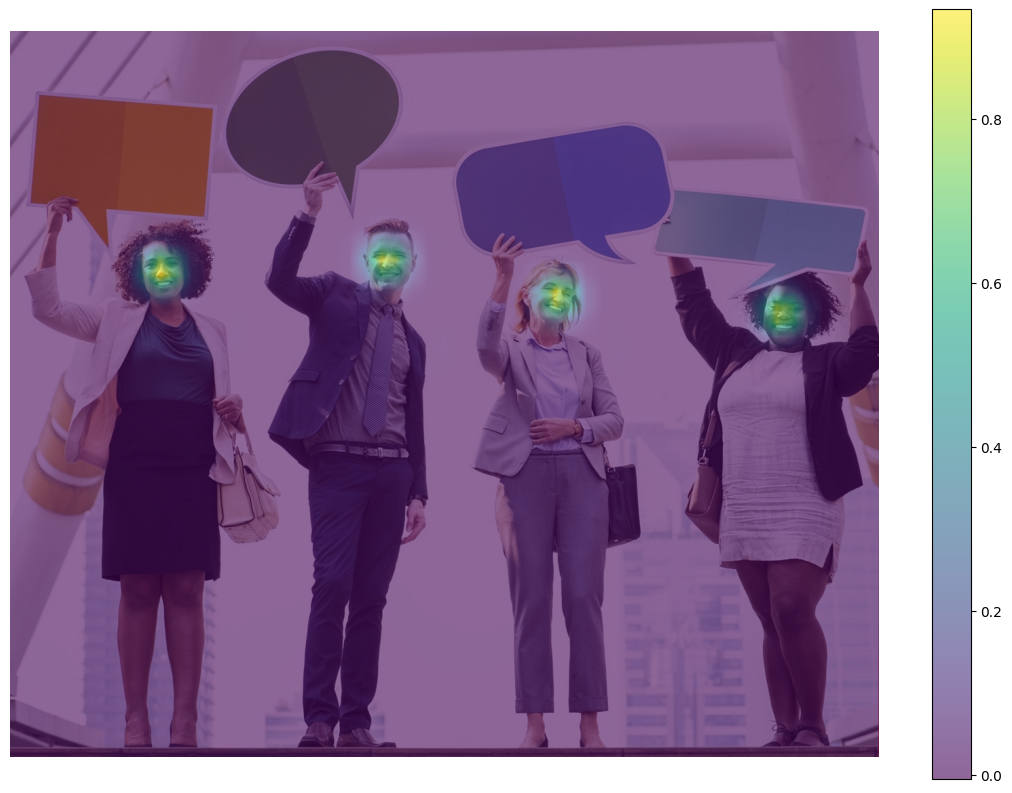

In [13]:
i = 0
probMap = output[0, i, :, :]
probMap = cv2.resize(probMap, (frameWidth, frameHeight))
plt.figure(figsize=[14,10])
plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
plt.imshow(probMap, alpha=0.6)
plt.colorbar()
plt.axis("off")

In [18]:
detected_keypoints = []
keypoints_list = np.zeros((0,3))
keypoint_id = 0
threshold = 0.1

for part in range(nPoints):
    probMap = output[0,part,:,:]
    probMap = cv2.resize(probMap, (image1.shape[1], image1.shape[0]))
#     plt.figure()
#     plt.imshow(255*np.uint8(probMap>threshold))
    keypoints = getKeypoints(probMap, threshold)
    print("Keypoints - {} : {}".format(keypointsMapping[part], keypoints))
    keypoints_with_id = []
    for i in range(len(keypoints)):
        keypoints_with_id.append(keypoints[i] + (keypoint_id,))
        keypoints_list = np.vstack([keypoints_list, keypoints[i]])
        keypoint_id += 1

    detected_keypoints.append(keypoints_with_id)


Keypoints - Nose : [(1129, 409, np.float32(0.78874767)), (803, 385, np.float32(0.84395397)), (221, 360, np.float32(0.9333654)), (547, 338, np.float32(0.85792017))]
Keypoints - Neck : [(1130, 478, np.float32(0.7417625)), (801, 476, np.float32(0.72753054)), (221, 430, np.float32(0.8164109)), (546, 430, np.float32(0.81971043))]
Keypoints - R-Sho : [(1081, 477, np.float32(0.80219984)), (733, 454, np.float32(0.7895045)), (152, 430, np.float32(0.7059898)), (477, 385, np.float32(0.7577508))]
Keypoints - R-Elb : [(709, 454, np.float32(0.7108081)), (58, 407, np.float32(0.8001644)), (1012, 406, np.float32(0.7163536)), (385, 361, np.float32(0.7847566))]
Keypoints - R-Wr : [(338, 594, np.float32(0.118025355)), (732, 361, np.float32(0.81081885)), (967, 313, np.float32(0.537506)), (58, 291, np.float32(0.68806237)), (430, 268, np.float32(0.85019135))]
Keypoints - L-Sho : [(1199, 500, np.float32(0.7946307)), (849, 477, np.float32(0.85449195)), (593, 454, np.float32(0.8797664)), (291, 431, np.float32(0

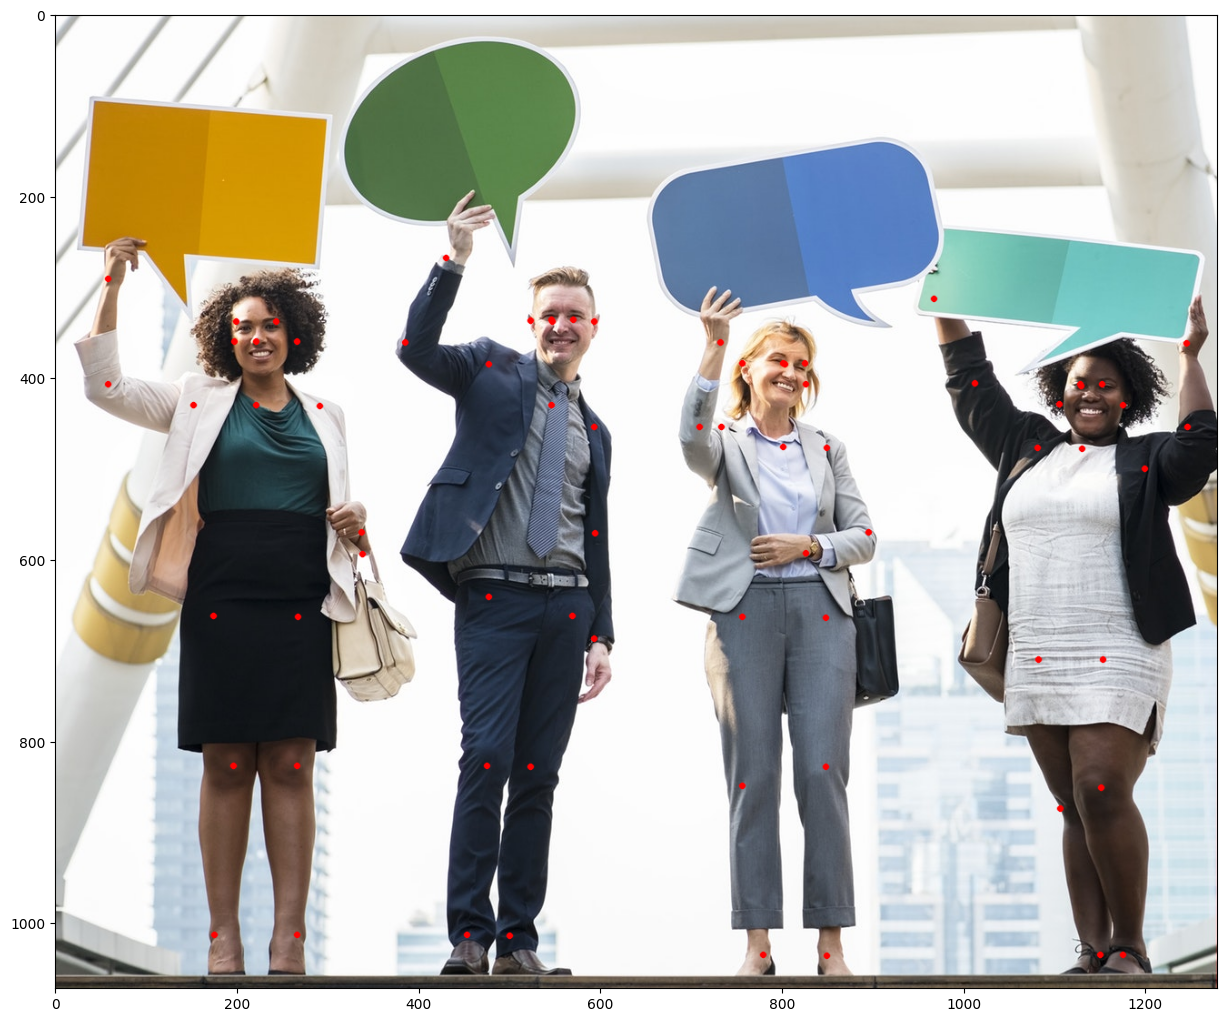

In [19]:
frameClone = image1.copy()
for i in range(nPoints):
    for j in range(len(detected_keypoints[i])):
        cv2.circle(frameClone, detected_keypoints[i][j][0:2], 3, [0,0,255], -1, cv2.LINE_AA)
plt.figure(figsize=[15,15])
plt.imshow(frameClone[:,:,[2,1,0]])

In [20]:
valid_pairs, invalid_pairs = getValidPairs(output)

[array([[ 4.        ,  8.        ,  0.89929166],
       [ 5.        ,  9.        ,  0.88005985],
       [ 6.        , 10.        ,  0.91600463],
       [ 7.        , 11.        ,  0.82639861]]), array([[ 4.        , 21.        ,  0.84519439],
       [ 5.        , 22.        ,  1.01198395],
       [ 6.        , 24.        ,  0.94236452],
       [ 7.        , 23.        ,  0.93459165]]), array([[ 8.        , 14.        ,  1.01884913],
       [ 9.        , 12.        ,  0.77580564],
       [10.        , 13.        ,  0.88964102],
       [11.        , 15.        ,  0.80308178]]), array([[12.        , 17.        ,  0.89793842],
       [13.        , 19.        ,  0.85838283],
       [14.        , 18.        ,  0.78781629],
       [15.        , 20.        ,  0.61500876]]), array([[21.        , 27.        ,  0.55072778],
       [22.        , 26.        ,  0.96840698],
       [23.        , 25.        ,  0.79322047]]), array([[25.        , 28.        ,  0.72754448],
       [26.        , 30.     

In [21]:
personwiseKeypoints = getPersonwiseKeypoints(valid_pairs, invalid_pairs)

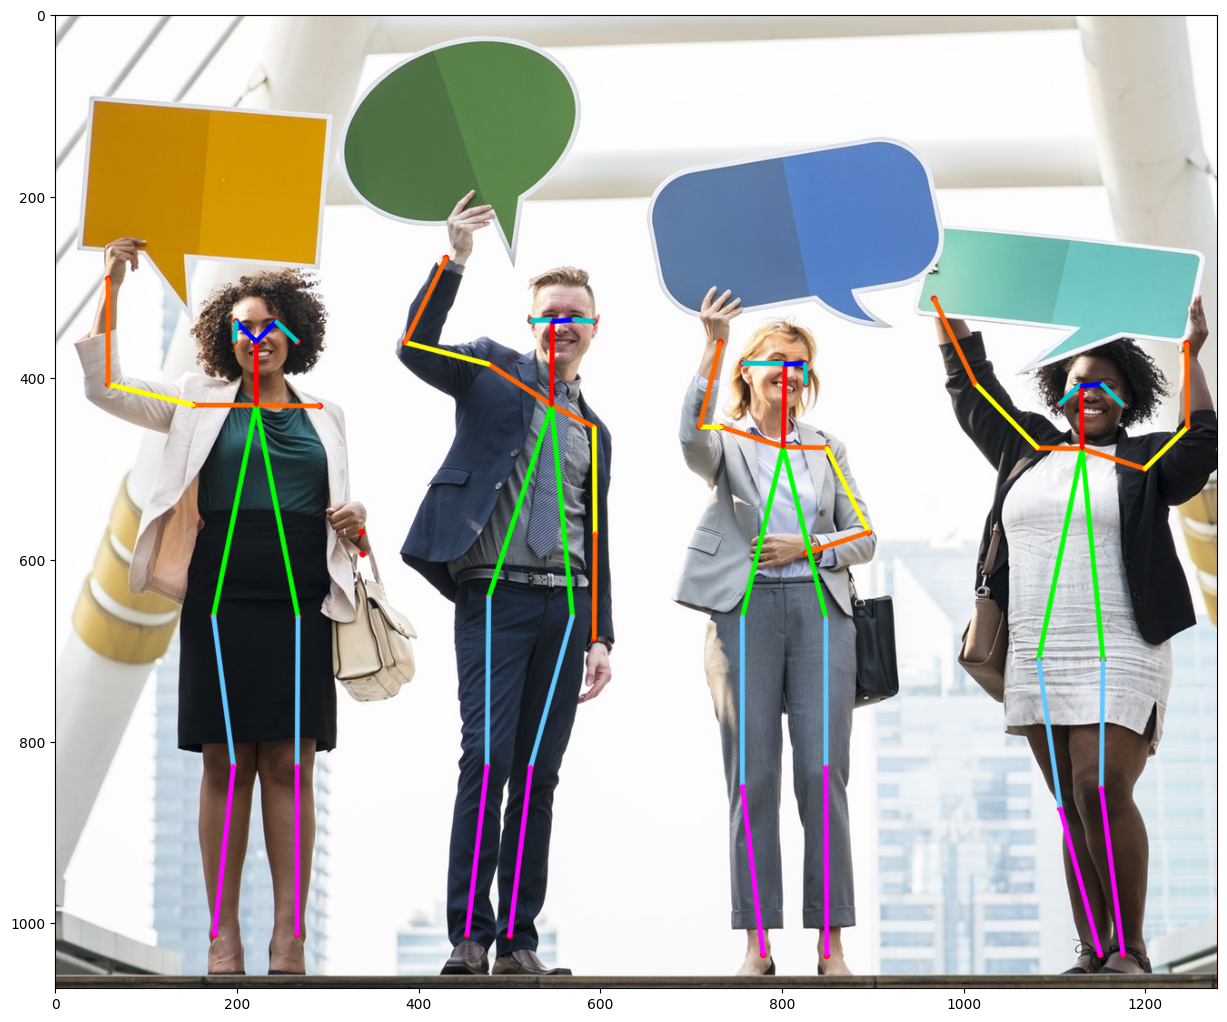

In [22]:
for i in range(17):
    for n in range(len(personwiseKeypoints)):
        index = personwiseKeypoints[n][np.array(POSE_PAIRS[i])]
        if -1 in index:
            continue
        B = np.int32(keypoints_list[index.astype(int), 0])
        A = np.int32(keypoints_list[index.astype(int), 1])
        cv2.line(frameClone, (B[0], A[0]), (B[1], A[1]), colors[i], 3, cv2.LINE_AA)
        
plt.figure(figsize=[15,15])
plt.imshow(frameClone[:,:,[2,1,0]])